In [1]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint

In [2]:
import sys 
sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule


In [6]:
path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrain_slope.yml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [7]:
model = AttentionalTrackingModule(config)

In [8]:
!ls ../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4/checkpoints/

epoch=0-step=65000-v1.ckpt  epoch=0-step=65000.ckpt


In [9]:
ckpt_path = '../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_norm_at_input_pos_slope_bs_64_lr_1e-4/' \
'checkpoints/epoch=0-step=65000.ckpt'

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model.load_state_dict(ckpt['state_dict'])


<All keys matched successfully>

In [10]:
attn_params = model.attn_modules

In [11]:
[param for param in attn_params[0].named_parameters()]

[('bias',
  Parameter containing:
  tensor([0.0615], requires_grad=True)),
 ('slope',
  Parameter containing:
  tensor([1.2350], requires_grad=True)),
 ('threshold',
  Parameter containing:
  tensor([0.1895], requires_grad=True))]

In [12]:
attn_params[0].bias.item()

0.06151913106441498

In [13]:
n_attn_blocks = len(attn_params)

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Plot attentional filters

In [15]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [16]:
n_attn_blocks

8

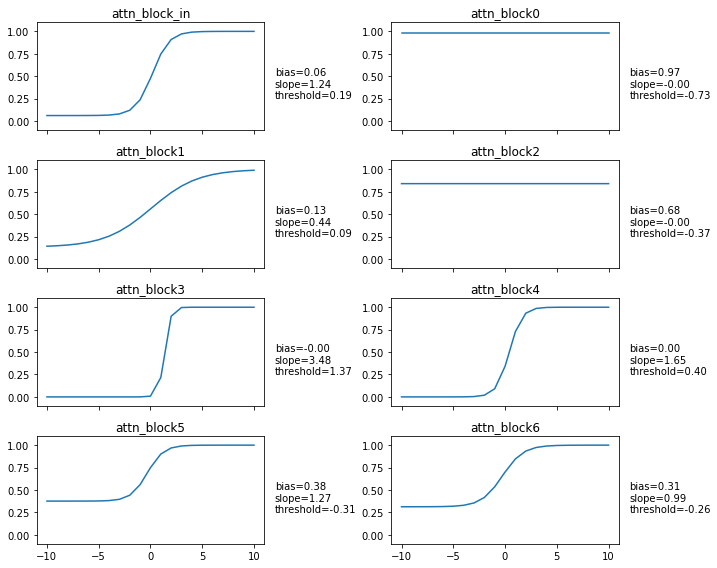

In [27]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(10,8))
axs = axs.ravel()
layer_names = [name for name in model._modules['model']._modules.keys() if 'attn' in name]
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-10,11)

for i in range(n_attn_blocks):
    bias = attn_params[i].bias.item()
    slope = attn_params[i].slope.item()
    threshold = attn_params[i].threshold.item()
    
    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(12, 0.25, f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    axs[i].set_ylim(-0.1,1.1)
#     axs[i].set_xlim(-1,1)

    
    
plt.tight_layout()
plt.

## Plot constrained model's parameters

In [ ]:
path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrain_slope.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)